# CS 415 - Project 2: Exploratory Data Analysis

This notebook performs the data analysis for Project 2. It loads collected data from Twitch and YouTube, cleans it, and generates styled visualizations.

**Figures Generated:**
* Figure 1: Daily Collection Volume
* Figure 2: Toxicity Score Distribution
* Figure 3: Cross-Platform Engagement Scatter Plot
* Figure 4: Peak Twitch Viewership Times
* Figure 5: Twitch Stream Title Analysis
* Figure 6: YouTube Video Title Analysis
* Figure 7: YouTube Description Analysis
* Figure 8: Community Reaction to Toxicity
* Figure 9: Comments per Video Distribution
* Figure 10: Toxicity Trends Over Time
* Figure 10: Top Creators Ranking

## 1. Global Setup & Style Configuration

We import necessary libraries and define a consistent visual theme (colors, fonts, sizes) for all plots.

In [1]:
import os
import nltk
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.feature_extraction.text import CountVectorizer

# --- Visual Style Configuration ---
# Set the aesthetic style of the plots to look professional in a paper
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Define Custom Brand Colors for consistency across figures
PALETTE_PLATFORMS = {"Twitch Snapshots": "#9146FF", "YouTube Comments": "#FF0000"}
PALETTE_TOXIC = "flare" # Red/Orange gradient
PALETTE_RANKING = "viridis" # Green/Blue/Purple gradient
COLOR_TWITCH = "#9146FF"
COLOR_YOUTUBE = "#FF0000"
COLOR_NEUTRAL = "#2ca02c"

# Plot params for high resolution
plt.rcParams['figure.dpi'] = 150 
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 12

# File Paths
FILE_TWITCH_STREAMS = "twitch_streams_data.csv"
FILE_TWITCH_USERS = "twitch_users_data.csv"
FILE_YT_VIDEOS = "youtube_videos_data.csv"
FILE_YT_COMMENTS = "youtube_comments_data.csv"
FILE_STREAMER_MAP = "streamer_map.csv"

warnings.filterwarnings('ignore')

# Stopword Configuration
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download('stopwords')

# Create a global set of stopwords to use for ALL text analysis figures
def get_master_stopwords():
    stop_words = set()
    # 1. Add Multilingual Support
    for lang in ['english', 'spanish', 'french', 'german', 'portuguese', 'italian']:
        try:
            stop_words.update(nltk.corpus.stopwords.words(lang))
        except OSError:
            print(f"Warning: Stopwords for {lang} not found.")

    # 2. Add Custom Ignore Words
    custom_words = [
        # Common Filler/Stream Terms
        'irl', 'just', 'chatting', 'stream', 'live', 'day', 'vs', 'new', 'get', 'w', 'react', 'reacts',
        'video', 'watch', 'watching', 'funny', 'moments', 'reaction', 'twitch', 'clips', 'clip',
        'today', 'now', 'best', 'worst', 'top', 'official', 'holy', 'meme', 'memes', 'fun', 'epic',
        'omg', 'wow', 'insane', 'crazy', 'hilarious', 'unbelievable', 'try', 'fails', 'compilation',
        'reactions', 'streaming', 'banger', 'bangers',
        # Platforms/Socials
        'instagram', 'insta', 'tiktok', 'twitter', 'discord', 'youtube', 'socials', 'link', 'shorts',
        # Engagement/Events
        'giveaway', 'streamer', 'community', 'sub', 'subs', 'subscriber', 'subscribers',
        'follower', 'followers', 'follow', 'like', 'chat', 'viewer', 'viewers', 'join', 'support',
        'prime', 'tag', 'tags', 'drop', 'drops', 'goal', 'partner', 'road',
        # Gaming Generic
        'game', 'games', 'gaming', 'gameplay', 'play', 'playing', 'player', 'solo', 'duo', 'squad',
        'rank', 'ranked', 'comp', 'competitive', 'pro', 'noob', 'win', 'wins', 'victory', 'lose',
        'fail', 'fails', 'update', 'patch', 'notes', 'new', 'season', 'episode', 'part',
        # Tech/Format
        'hd', 'hq', '4k', '1080p', '60fps', 'cam', 'facecam', 'mic', 'audio', 'vod', 'rerun',
        'full', 'highlights', 'highlight', 'compilation', 'montage', 'review', 'guide', 'tutorial'
    ]
    stop_words.update(custom_words)
    return list(stop_words)

MASTER_STOPWORDS = get_master_stopwords()

## 2. Load Datasets

In [2]:
dataframes = {}
files = {
    'twitch_df': FILE_TWITCH_STREAMS,
    'users_df': FILE_TWITCH_USERS,
    'videos_df': FILE_YT_VIDEOS,
    'comments_df': FILE_YT_COMMENTS,
    'map_df': FILE_STREAMER_MAP
}

for df_name, file_path in files.items():
    try:
        df = pd.read_csv(file_path, dtype={
            'user_id': str, 'stream_id': str,
            'video_id': str, 'channel_id': str,
            'youtube_channel_id': str, 'comment_id': str
        })
        dataframes[df_name] = df
        print(f"Successfully loaded {file_path} ({len(df)} rows)")
    except FileNotFoundError:
        print(f"WARNING: Could not find {file_path}. Some analyses may fail.")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

globals().update(dataframes)

Successfully loaded twitch_streams_data.csv (447422 rows)
Successfully loaded twitch_users_data.csv (5559 rows)
Successfully loaded youtube_videos_data.csv (54564 rows)
Successfully loaded youtube_comments_data.csv (1495081 rows)
Successfully loaded streamer_map.csv (2816 rows)


## 3. Data Pre-processing

In [3]:
# 3.1 Parse Timestamps
if 'twitch_df' in globals():
    twitch_df['collection_timestamp'] = pd.to_datetime(twitch_df['collection_timestamp'], errors='coerce')
    twitch_df.dropna(subset=['collection_timestamp'], inplace=True)
    print("Parsed 'collection_timestamp' in twitch_df.")

if 'comments_df' in globals():
    comments_df['published_at'] = pd.to_datetime(comments_df['published_at'], errors='coerce')
    comments_df.dropna(subset=['published_at'], inplace=True)
    print("Parsed 'published_at' in comments_df.")

if 'videos_df' in globals():
    videos_df['published_at'] = pd.to_datetime(videos_df['published_at'], errors='coerce')
    videos_df.dropna(subset=['published_at'], inplace=True)
    print("Parsed 'published_at' in videos_df.")

# 3.2 Toxicity Score Validation (Simulate if missing for demonstration)
if 'comments_df' in globals():
    if 'toxicity_score' not in comments_df.columns:
        print("WARNING: 'toxicity_score' column not found! Creating dummy data for visualization.")
        comments_df['toxicity_score'] = np.random.beta(0.5, 5, size=len(comments_df))
    else:
        comments_df['toxicity_score'] = pd.to_numeric(comments_df['toxicity_score'], errors='coerce')
        print("Validated 'toxicity_score' column.")

Parsed 'collection_timestamp' in twitch_df.
Parsed 'published_at' in comments_df.
Parsed 'published_at' in videos_df.
Validated 'toxicity_score' column.


## 4. Analysis 1: Dataset Overview (Table 1)

In [4]:
summary_data = []

if 'twitch_df' in globals():
    summary_data.append({
        'Dataset': 'Twitch Streams', 
        'Total Rows': len(twitch_df),
        'File Size (MB)': os.path.getsize(FILE_TWITCH_STREAMS) / (1024*1024),
        'Date Range': f"{twitch_df['collection_timestamp'].min().date()} to {twitch_df['collection_timestamp'].max().date()}",
        'Unique Users': twitch_df['user_id'].nunique()
    })

if 'users_df' in globals():
    summary_data.append({
        'Dataset': 'Twitch Users', 
        'Total Rows': len(users_df),
        'File Size (MB)': os.path.getsize(FILE_TWITCH_USERS) / (1024*1024),
        'Date Range': 'N/A',
        'Unique Users': users_df['user_id'].nunique()
    })

if 'videos_df' in globals():
    summary_data.append({
        'Dataset': 'YouTube Videos', 
        'Total Rows': len(videos_df),
        'File Size (MB)': os.path.getsize(FILE_YT_VIDEOS) / (1024*1024),
        'Date Range': f"{videos_df['published_at'].min().date()} to {videos_df['published_at'].max().date()}",
        'Unique Users': videos_df['channel_id'].nunique()
    })

if 'comments_df' in globals():
    summary_data.append({
        'Dataset': 'YouTube Comments', 
        'Total Rows': len(comments_df),
        'File Size (MB)': os.path.getsize(FILE_YT_COMMENTS) / (1024*1024),
        'Date Range': f"{comments_df['published_at'].min().date()} to {comments_df['published_at'].max().date()}",
        'Unique Users': comments_df['author_name'].nunique()
    })

if 'map_df' in globals():
    summary_data.append({
        'Dataset': 'Streamer Map', 
        'Total Rows': len(map_df),
        'File Size (MB)': os.path.getsize(FILE_STREAMER_MAP) / (1024*1024),
        'Date Range': 'N/A',
        'Unique Users': map_df['twitch_login_name'].nunique()
    })

summary_table = pd.DataFrame(summary_data).set_index('Dataset')
print("Table 1: Dataset Summary")
display(summary_table)

Table 1: Dataset Summary


,Total Rows,File Size (MB),Date Range,Unique Users
Dataset,,,,
Twitch Streams,447422,100.281386,2025-10-16 to 2025-12-03,5625
Twitch Users,5559,1.405117,N/A,5559
YouTube Videos,54564,34.497277,2008-05-05 to 2025-12-03,2769
YouTube Comments,1495081,260.148187,2008-09-09 to 2025-12-03,1032932
Streamer Map,2816,0.094778,N/A,2816


## 5. Analysis 2: Daily Collection Volume (Figure 1)
Shows data ingestion rates over time, colored by platform branding.

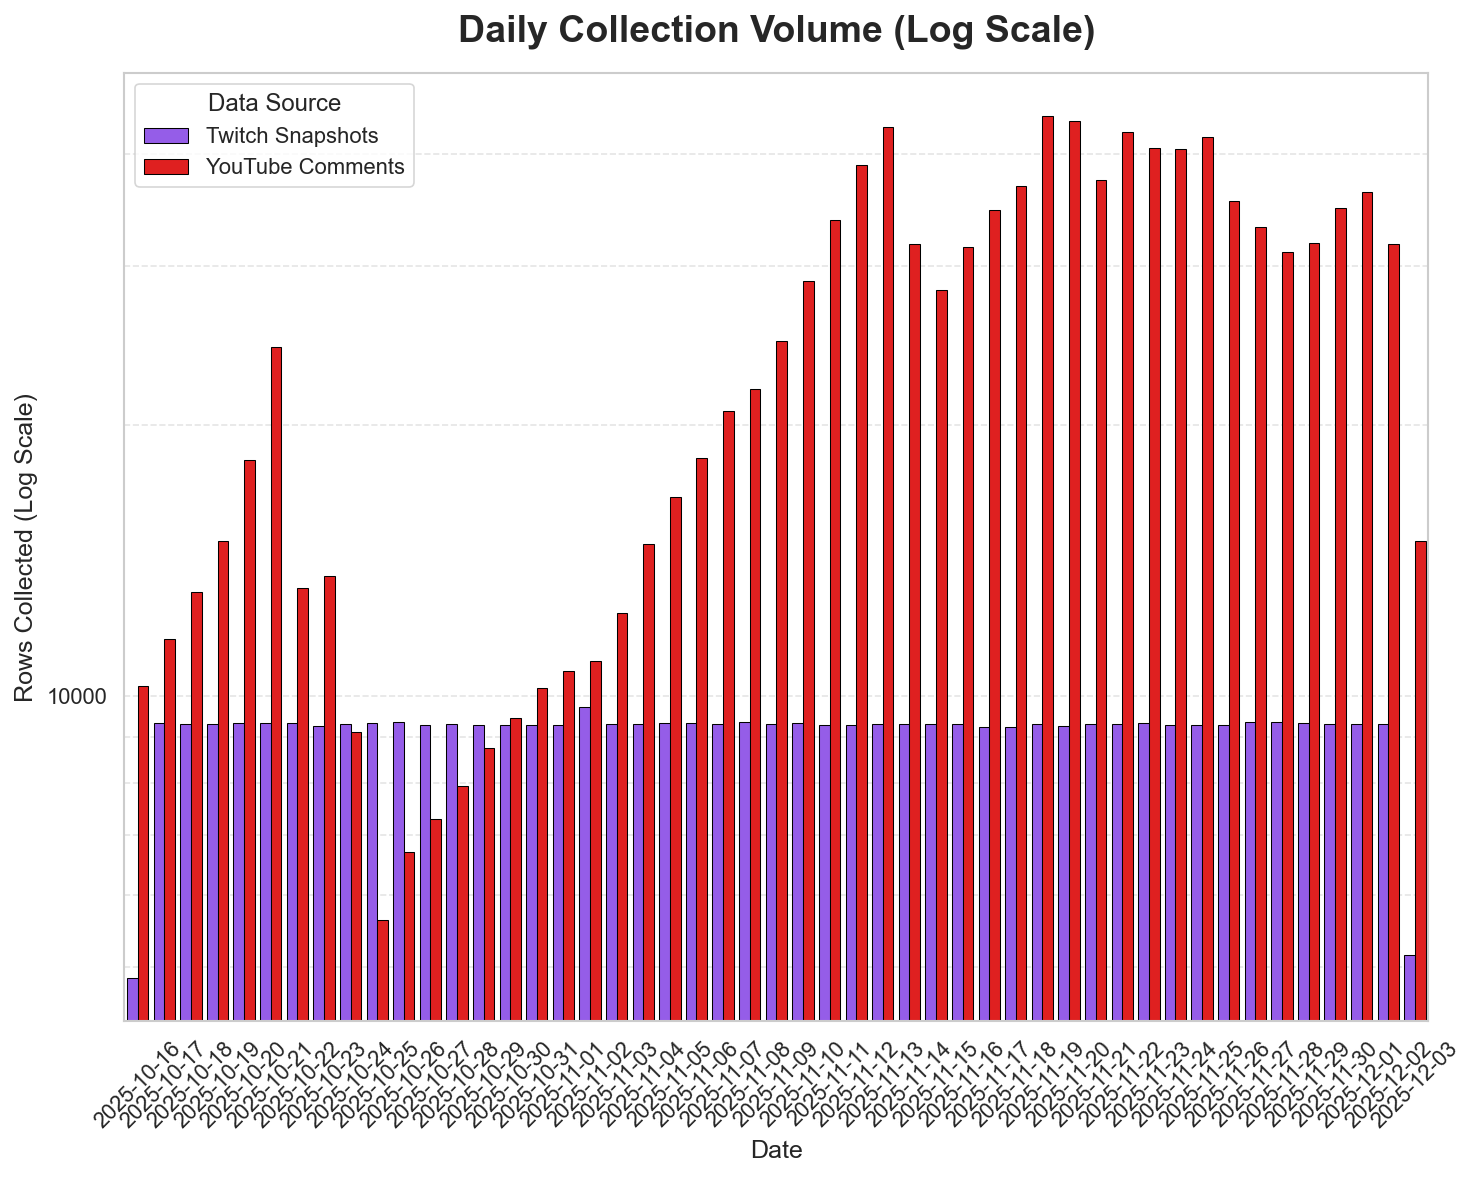

In [5]:
if 'twitch_df' in globals() and 'comments_df' in globals():
    # Aggregate Twitch Data
    twitch_daily = twitch_df.set_index('collection_timestamp').resample('D').size().reset_index(name='count')
    twitch_daily.rename(columns={'collection_timestamp': 'Date'}, inplace=True)
    twitch_daily['Source'] = 'Twitch Snapshots'
    
    # Aggregate YouTube Data
    comments_daily = comments_df.set_index('published_at').resample('D').size().reset_index(name='count')
    comments_daily.rename(columns={'published_at': 'Date'}, inplace=True)
    comments_daily['Source'] = 'YouTube Comments'
    
    twitch_daily['Date'] = pd.to_datetime(twitch_daily['Date'], utc=True).dt.tz_localize(None)
    comments_daily['Date'] = pd.to_datetime(comments_daily['Date'], utc=True).dt.tz_localize(None)

    # 3. Filter Date Range to "Active Collection Period"
    start_date = twitch_daily['Date'].min()
    end_date = twitch_daily['Date'].max()
    
    # Combine and Filter
    daily_counts = pd.concat([twitch_daily, comments_daily], ignore_index=True)
    
    daily_counts = daily_counts[
        (daily_counts['Date'] >= start_date) & 
        (daily_counts['Date'] <= end_date)
    ]
    
    # 4. Plot with Log Scale
    plt.figure(figsize=(10, 8))
    
    ax = sns.barplot(
        data=daily_counts, 
        x=daily_counts['Date'].dt.date, 
        y='count', 
        hue='Source', 
        palette=PALETTE_PLATFORMS,
        edgecolor='black',
        linewidth=0.5
    )
    
    ax.set_yscale("log")
    
    # Formatting
    plt.title(f'Daily Collection Volume (Log Scale)', weight='bold', pad=15)
    plt.ylabel('Rows Collected (Log Scale)')
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    
    plt.legend(title='Data Source')
    plt.grid(axis='y', linestyle='--', alpha=0.5, which='both')
    
    plt.tight_layout()
    plt.savefig("figure_1_collection_volume.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Skipping Figure 1: Missing Twitch or YouTube data.")

## 6. Analysis 3: Toxicity Distribution (Figure 2)
Distribution of scores using a red color theme to indicate 'toxicity'.

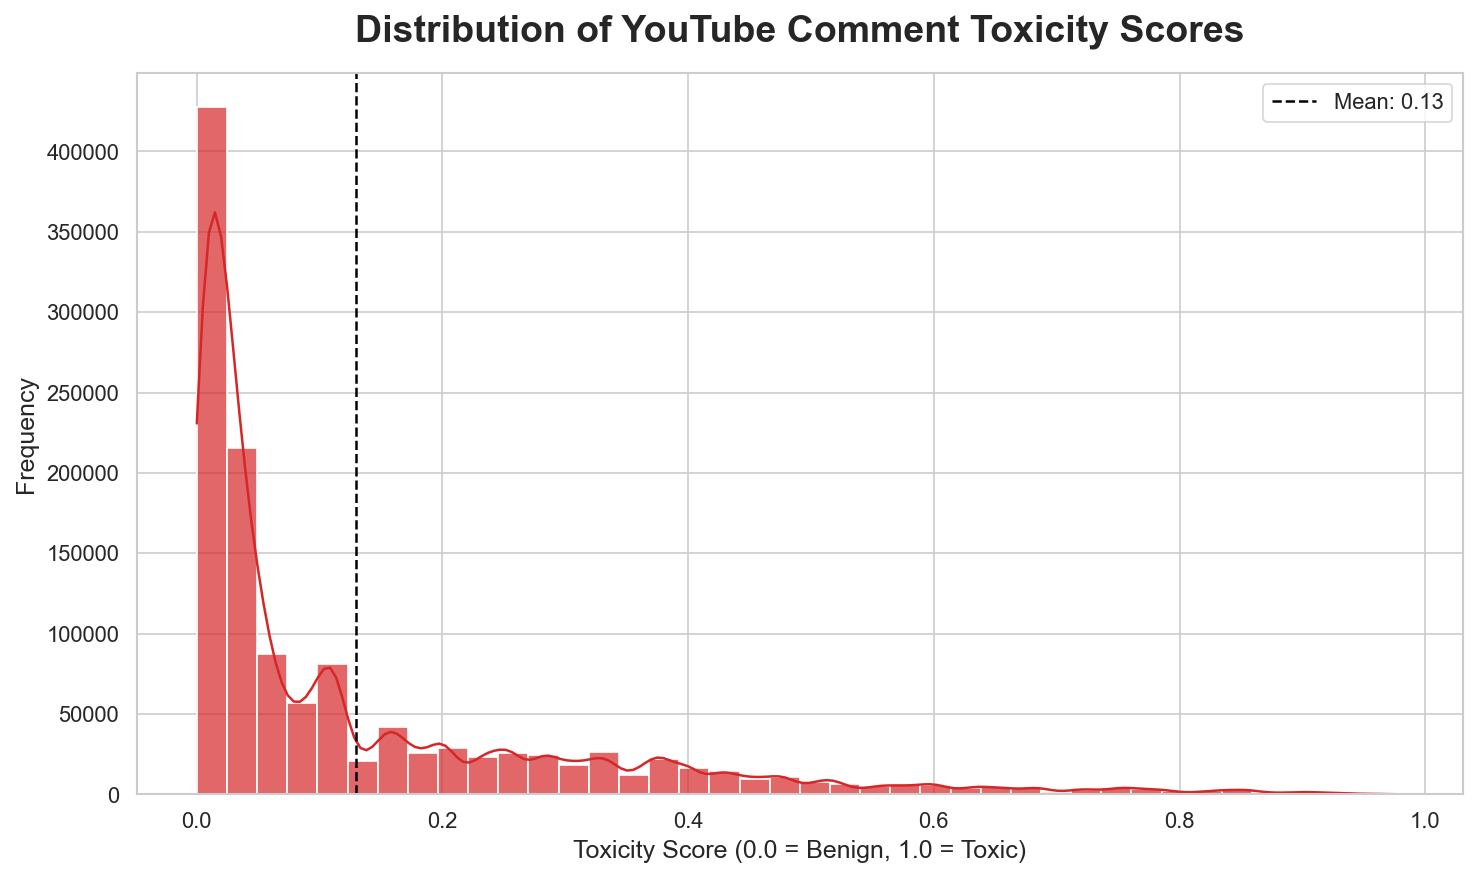

In [6]:
if 'comments_df' in globals():
    plot_df = comments_df.dropna(subset=['toxicity_score'])
    
    if not plot_df.empty:
        plt.figure(figsize=(10, 6))
        
        sns.histplot(
            plot_df['toxicity_score'], 
            bins=40, 
            kde=True, 
            color="#d62728",
            edgecolor="white",
            alpha=0.7
        )
        
        plt.title('Distribution of YouTube Comment Toxicity Scores', weight='bold', pad=15)
        plt.xlabel('Toxicity Score (0.0 = Benign, 1.0 = Toxic)')
        plt.ylabel('Frequency')
        
        # Mean line
        mean_val = plot_df['toxicity_score'].mean()
        plt.axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val:.2f}')
        plt.legend()
        
        plt.tight_layout()
        plt.savefig("figure_2_toxicity_distribution.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Skipping Figure 2: No toxicity data found.")

## 7. Analysis 4: Cross-Platform Engagement (Figure 3)
Scatter plot correlating Twitch success with YouTube activity.

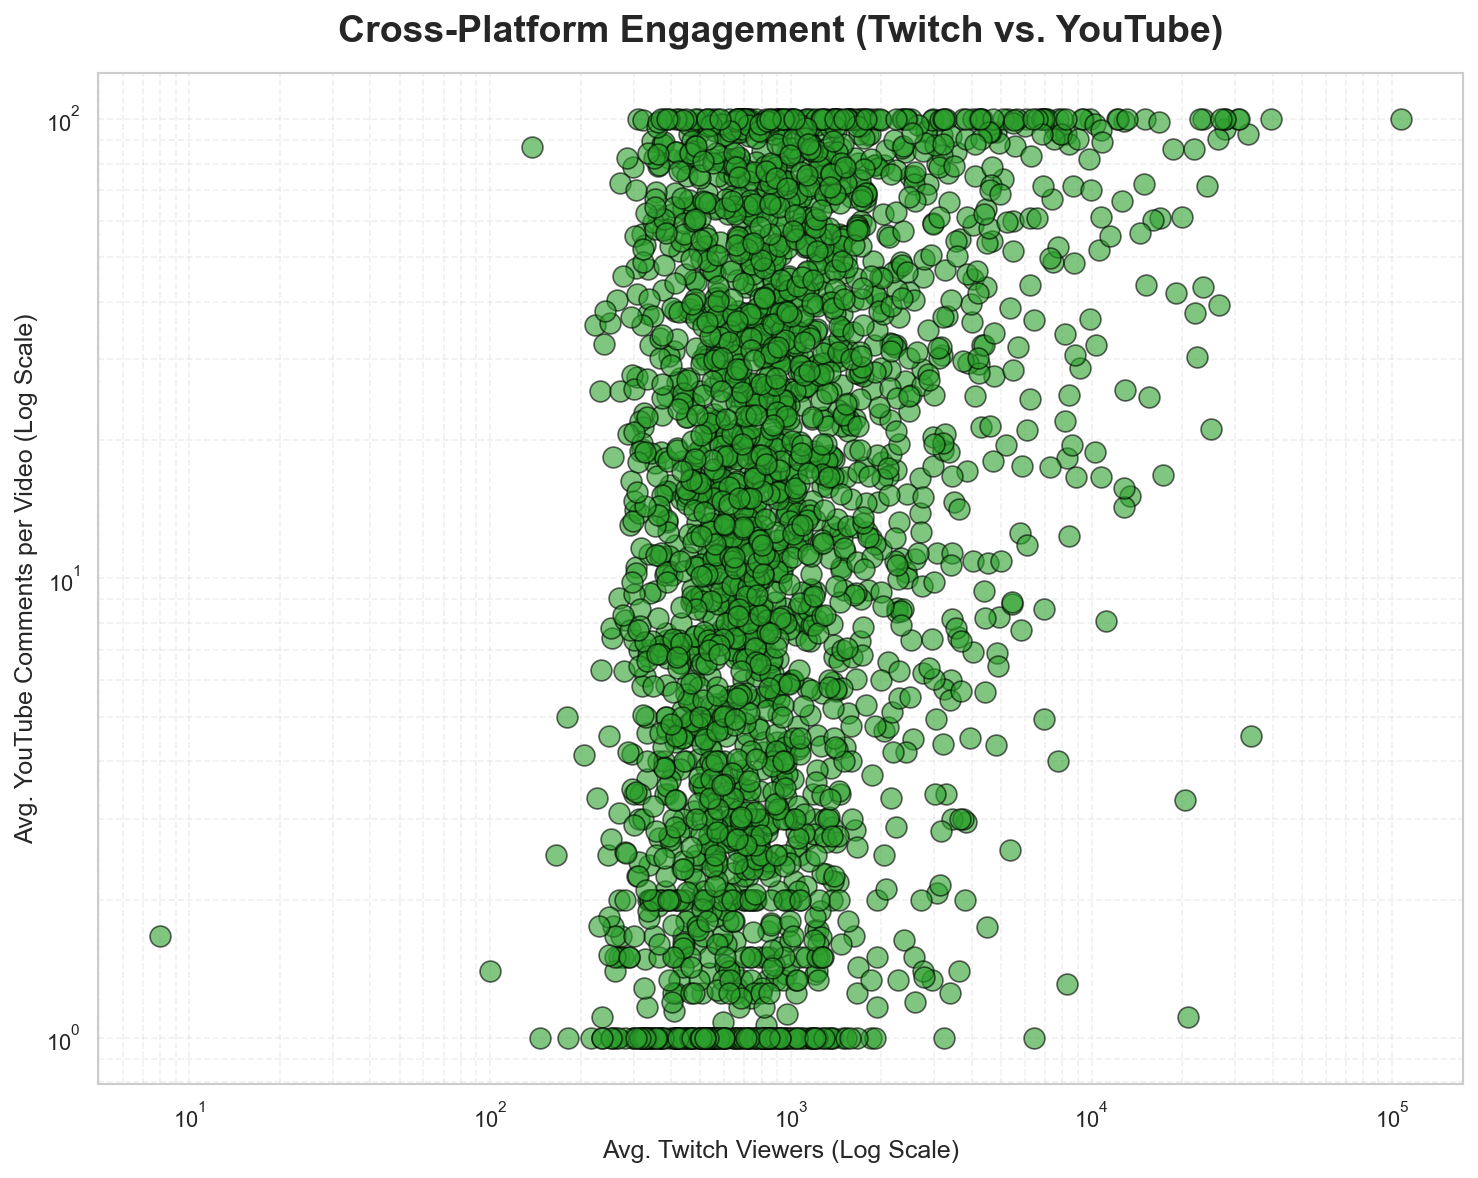

In [7]:
required_dfs = ['twitch_df', 'comments_df', 'videos_df', 'map_df', 'users_df']
missing_dfs = [df for df in required_dfs if df not in globals()]

if not missing_dfs:
    # Aggregate Twitch
    avg_twitch_viewers = twitch_df.groupby('user_id')['viewer_count'].mean().reset_index()
    
    # Aggregate YouTube
    comments_per_video = comments_df.groupby('video_id').size().reset_index(name='comment_count')
    
    if not comments_per_video.empty and not avg_twitch_viewers.empty:
        # Merging logic
        video_comment_counts = pd.merge(videos_df, comments_per_video, on='video_id')
        avg_yt_comments = video_comment_counts.groupby('channel_id')['comment_count'].mean().reset_index()
        mapped_yt_comments = pd.merge(avg_yt_comments, map_df, left_on='channel_id', right_on='youtube_channel_id')
        mapped_users_yt = pd.merge(mapped_yt_comments, users_df, left_on='twitch_login_name', right_on='login_name')
        cross_platform_df = pd.merge(avg_twitch_viewers, mapped_users_yt, on='user_id')

        if not cross_platform_df.empty:
            plt.figure(figsize=(10, 8))
            
            sns.scatterplot(
                data=cross_platform_df, 
                x='viewer_count', 
                y='comment_count',
                color=COLOR_NEUTRAL, 
                s=100, 
                alpha=0.6,
                edgecolor='black'
            )
            
            plt.title('Cross-Platform Engagement (Twitch vs. YouTube)', weight='bold', pad=15)
            plt.xlabel('Avg. Twitch Viewers (Log Scale)')
            plt.ylabel('Avg. YouTube Comments per Video (Log Scale)')
            plt.xscale('log')
            plt.yscale('log')
            plt.grid(True, which="both", ls="--", alpha=0.3)
            
            plt.tight_layout()
            plt.savefig("figure_3_cross_platform.png", dpi=300, bbox_inches='tight')
            plt.show()
        else:
            print("Skipping Figure 3: No overlapping users found.")
    else:
        print("Skipping Figure 3: Insufficient data for aggregation.")
else:
    print(f"Skipping Figure 3: Missing required dataframes {missing_dfs}")

## 8. Analysis 5: Peak Viewership Times (Figure 4)
Uses Twitch Purple branding.

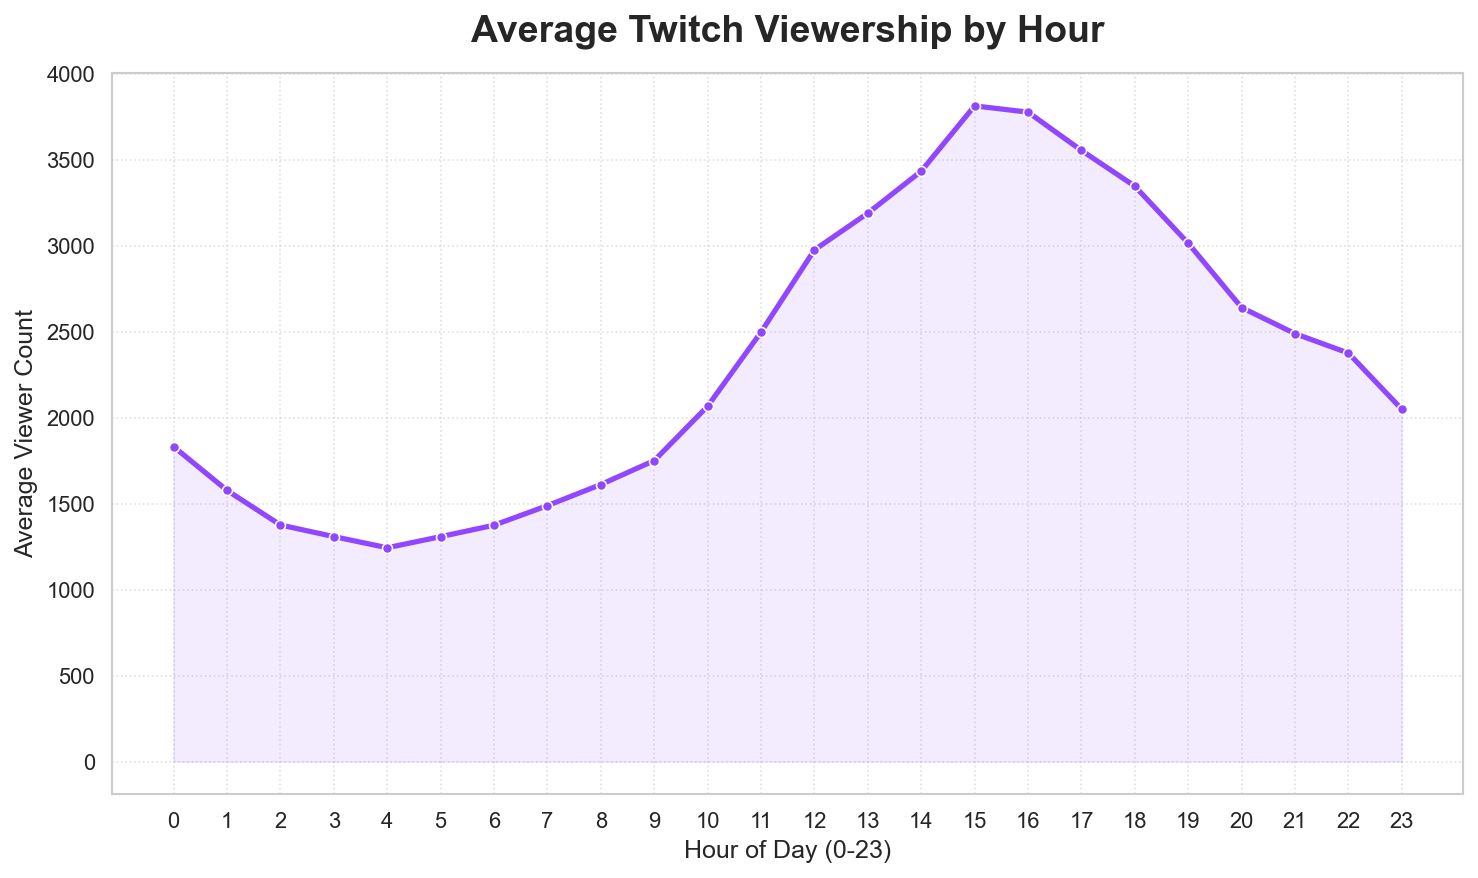

In [16]:
if 'twitch_df' in globals():
    twitch_df['hour_of_day'] = twitch_df['collection_timestamp'].dt.hour
    hourly_viewership = twitch_df.groupby('hour_of_day')['viewer_count'].mean().reset_index()
    
    plt.figure(figsize=(10, 6))
    
    sns.lineplot(
        data=hourly_viewership, 
        x='hour_of_day', 
        y='viewer_count', 
        marker='o', 
        color=COLOR_TWITCH, 
        linewidth=2.5
    )
    
    plt.fill_between(
        hourly_viewership['hour_of_day'], 
        hourly_viewership['viewer_count'], 
        color=COLOR_TWITCH, 
        alpha=0.1
    )
    
    plt.title('Average Twitch Viewership by Hour', weight='bold', pad=15)
    plt.xlabel('Hour of Day (0-23)')
    plt.ylabel('Average Viewer Count')
    plt.xticks(range(0, 24))
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig("figure_4_peak_viewership.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Skipping Figure 4: Missing Twitch data.")

## 9. Analysis 6: Content Analysis (Figure 5 - Twitch Titles)
Horizontal bar chart for better readability.

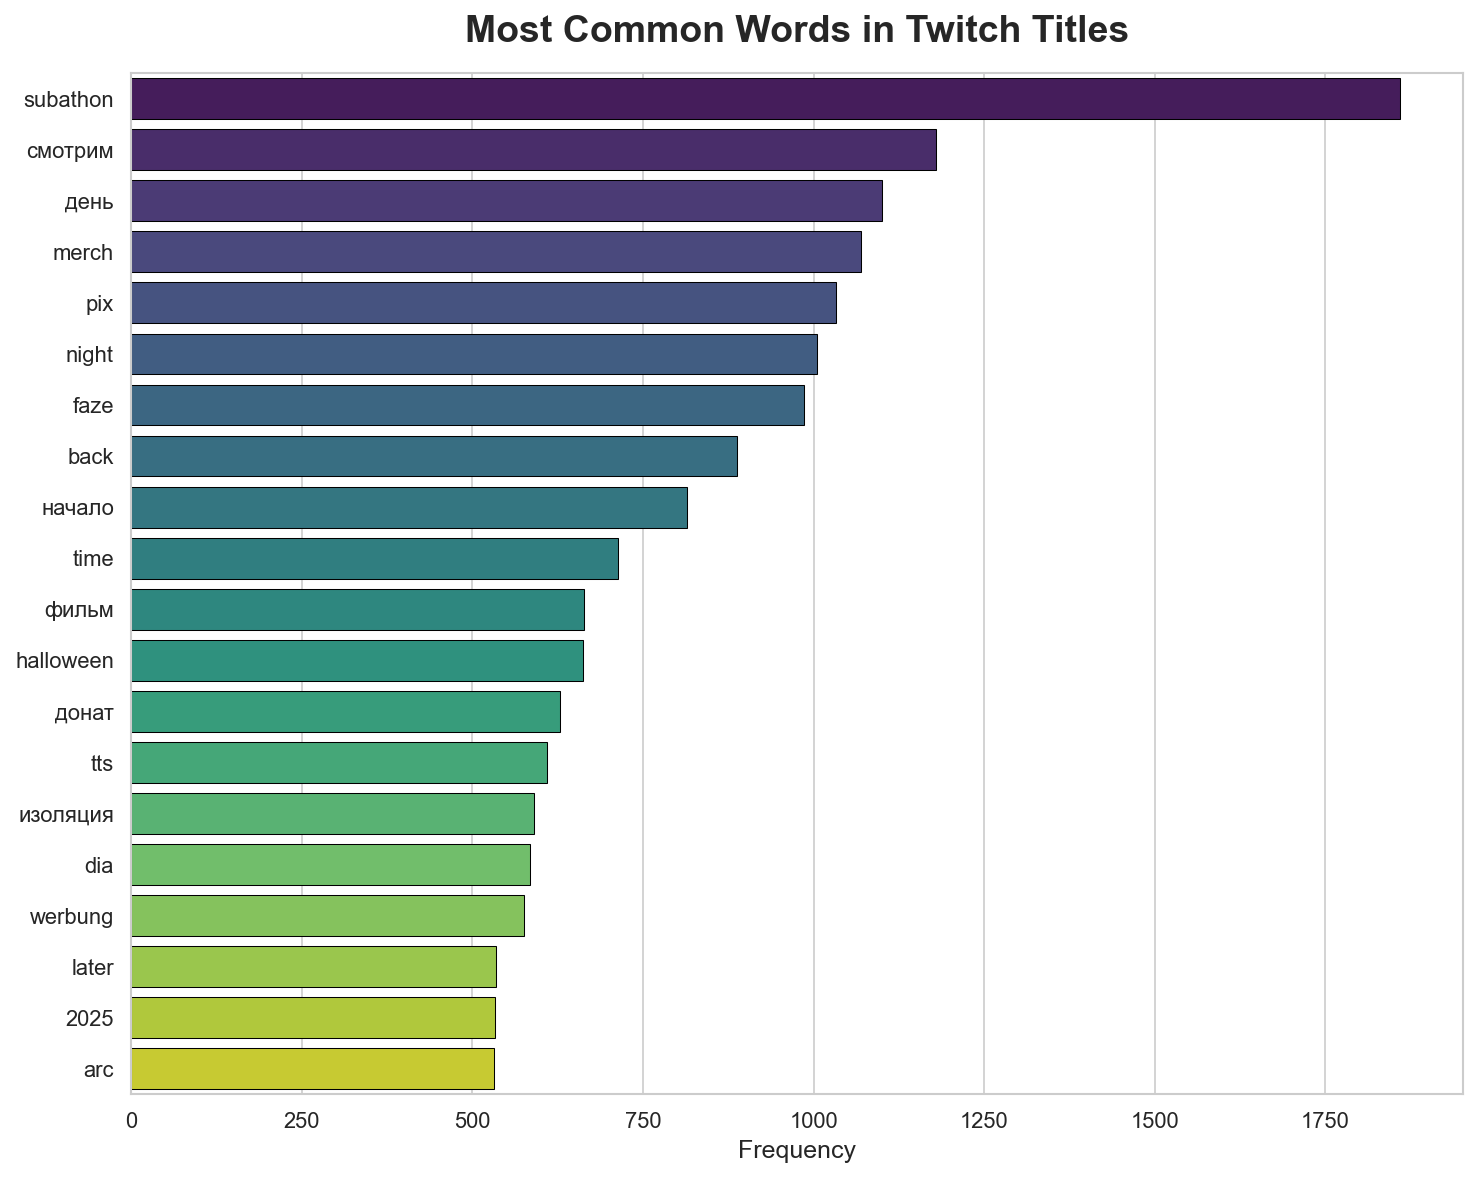

In [9]:
if 'twitch_df' in globals():
    try:
        titles_unique = twitch_df['stream_title'].dropna().drop_duplicates()

        vec = CountVectorizer(
            stop_words=MASTER_STOPWORDS,
            max_features=20,
            lowercase=True,
            token_pattern=r"(?u)\b\w{3,}\b"
        )
        bow = vec.fit_transform(titles_unique)
        word_counts = bow.sum(axis=0)

        words_df = pd.DataFrame({
            'word': vec.get_feature_names_out(),
            'count': np.asarray(word_counts)[0]
        }).sort_values('count', ascending=False)

        plt.figure(figsize=(10, 8))
        sns.barplot(
            data=words_df, 
            x='count', 
            y='word', 
            palette=PALETTE_RANKING,
            edgecolor='black',
            linewidth=0.5
        )
        
        plt.title('Most Common Words in Twitch Titles', weight='bold', pad=15)
        plt.xlabel('Frequency')
        plt.ylabel('')
        plt.tight_layout()
        plt.savefig("figure_5_twitch_title_content.png", dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Skipping Figure 5: Error - {e}")

## 10. Analysis 7: Content Analysis (Figure 6 - YouTube Titles)

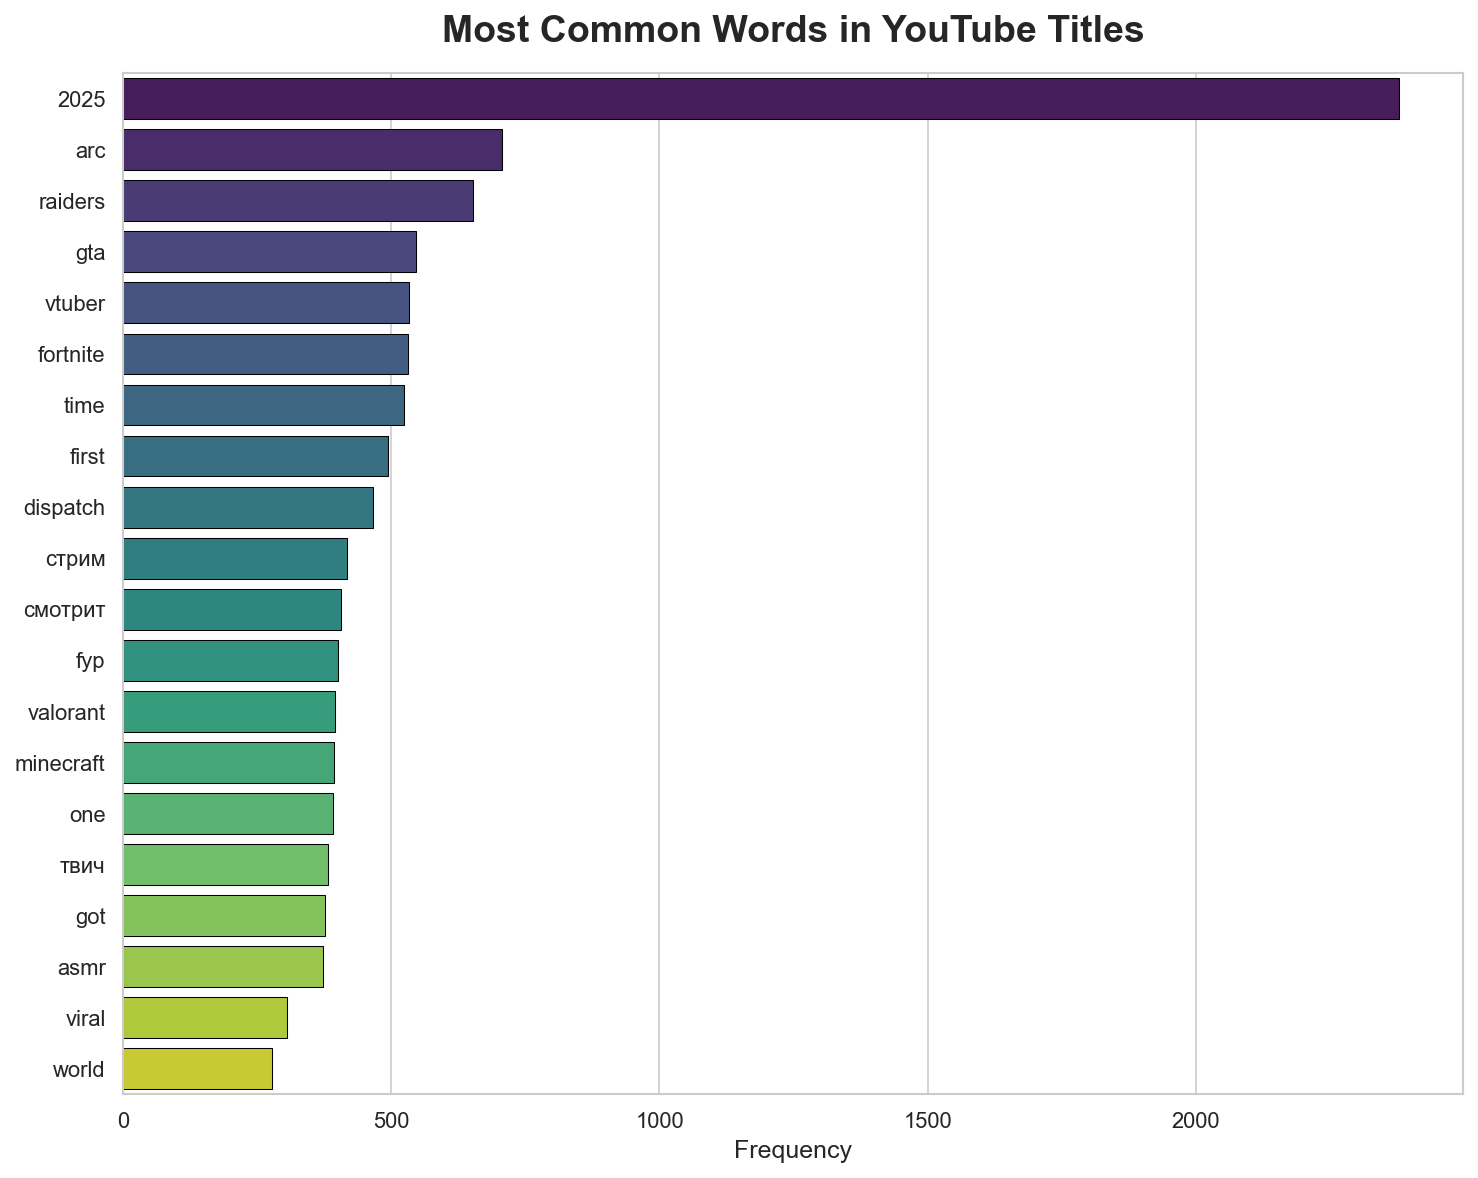

In [10]:
if 'videos_df' in globals():
    try:
        vec = CountVectorizer(
            stop_words=MASTER_STOPWORDS,
            max_features=20,
            lowercase=True,
            token_pattern=r"(?u)\b\w{3,}\b"
        )
        bow = vec.fit_transform(videos_df['video_title'].dropna())
        word_counts = bow.sum(axis=0)

        yt_words_df = pd.DataFrame({
            'word': vec.get_feature_names_out(),
            'count': np.asarray(word_counts)[0]
        }).sort_values('count', ascending=False)

        plt.figure(figsize=(10, 8))
        sns.barplot(data=yt_words_df, x='count', y='word', palette=PALETTE_RANKING, edgecolor='black', linewidth=0.5)
        plt.title('Most Common Words in YouTube Titles', weight='bold', pad=15)
        plt.xlabel('Frequency')
        plt.ylabel('')
        plt.tight_layout()
        plt.savefig("figure_6_youtube_title_content.png", dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Skipping Figure 6: Error - {e}")

## 11. Analysis 8: Content Analysis (Figure 7 - YouTube Descriptions)

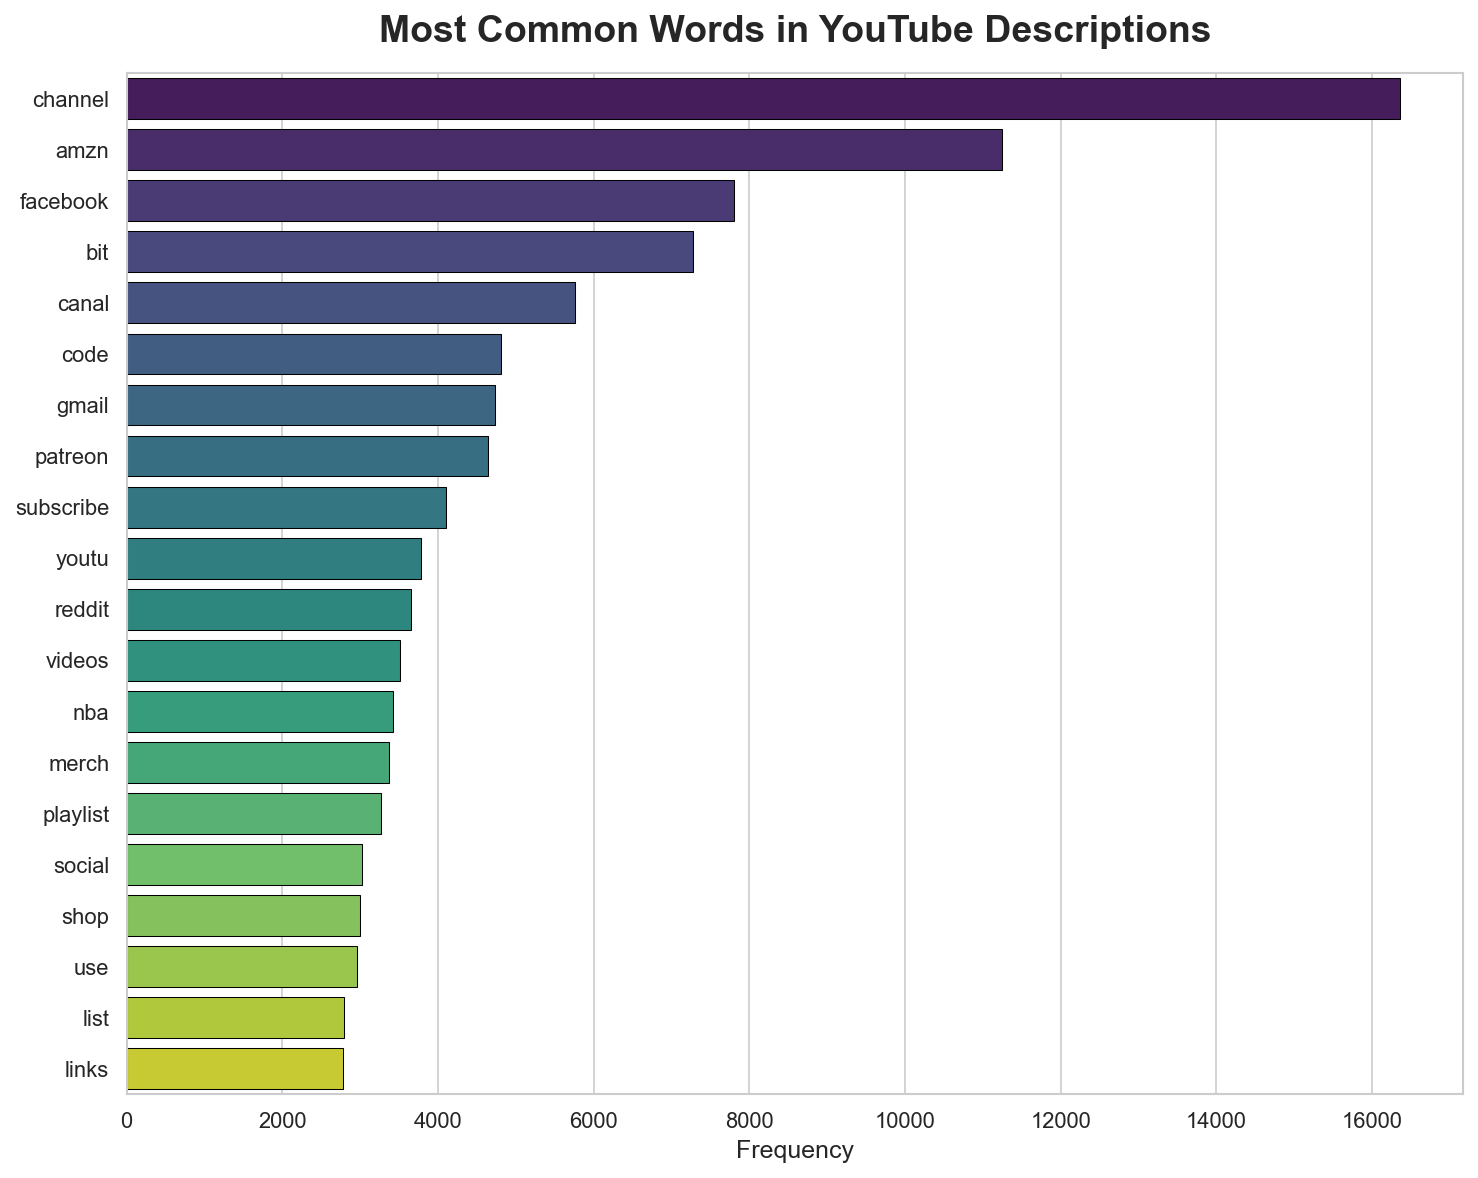

In [11]:
if 'videos_df' in globals():
    try:
        # Ensure URL patterns are ignored
        vec = CountVectorizer(
            stop_words=MASTER_STOPWORDS,
            max_features=20,
            lowercase=True,
            token_pattern=r"(?u)\b(?!https?://)(?!www\.)[a-zA-Z]{3,}\b" 
        )
        bow = vec.fit_transform(videos_df['video_description'].dropna())
        word_counts = bow.sum(axis=0)

        desc_words_df = pd.DataFrame({
            'word': vec.get_feature_names_out(),
            'count': np.asarray(word_counts)[0]
        }).sort_values('count', ascending=False)

        plt.figure(figsize=(10, 8))
        sns.barplot(data=desc_words_df, x='count', y='word', palette=PALETTE_RANKING, edgecolor='black', linewidth=0.5)
        plt.title('Most Common Words in YouTube Descriptions', weight='bold', pad=15)
        plt.xlabel('Frequency')
        plt.ylabel('')
        plt.tight_layout()
        plt.savefig("figure_7_youtube_description_content.png", dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Skipping Figure 7: Error - {e}")

## 12. Analysis 9: Community Reaction (Figure 8)
Boxplot showing the relationship between toxicity and engagement (Likes).

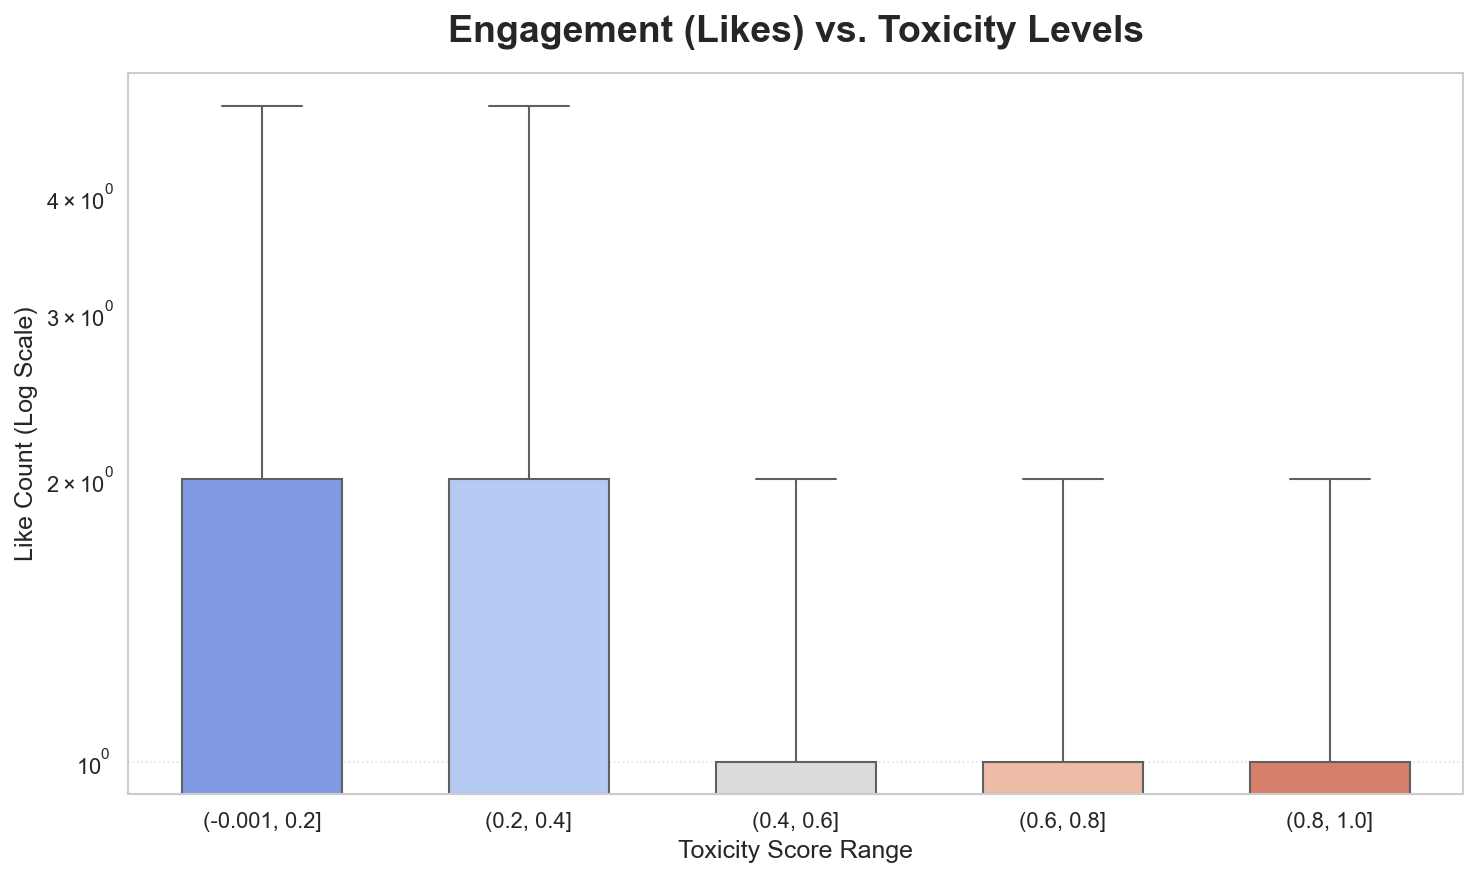

In [12]:
if 'comments_df' in globals():
    plot_df = comments_df.dropna(subset=['toxicity_score', 'like_count'])

    if not plot_df.empty:
        bin_edges = np.linspace(0, 1, 6)
        plot_df['toxicity_bin'] = pd.cut(plot_df['toxicity_score'], bins=bin_edges, include_lowest=True)

        plt.figure(figsize=(10, 6))
        
        sns.boxplot(
            data=plot_df,
            x='toxicity_bin',
            y='like_count',
            palette="coolwarm",
            width=0.6,
            showfliers=False
        )
        
        plt.yscale('log')
        plt.title('Engagement (Likes) vs. Toxicity Levels', weight='bold', pad=15)
        plt.xlabel('Toxicity Score Range')
        plt.ylabel('Like Count (Log Scale)')
        plt.grid(axis='y', linestyle=':', alpha=0.6)
        
        plt.tight_layout()
        plt.savefig("figure_8_toxicity_reaction.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Skipping Figure 8: No data.")

## 13. Analysis 10: Comments per Video Distribution (Figure 9)

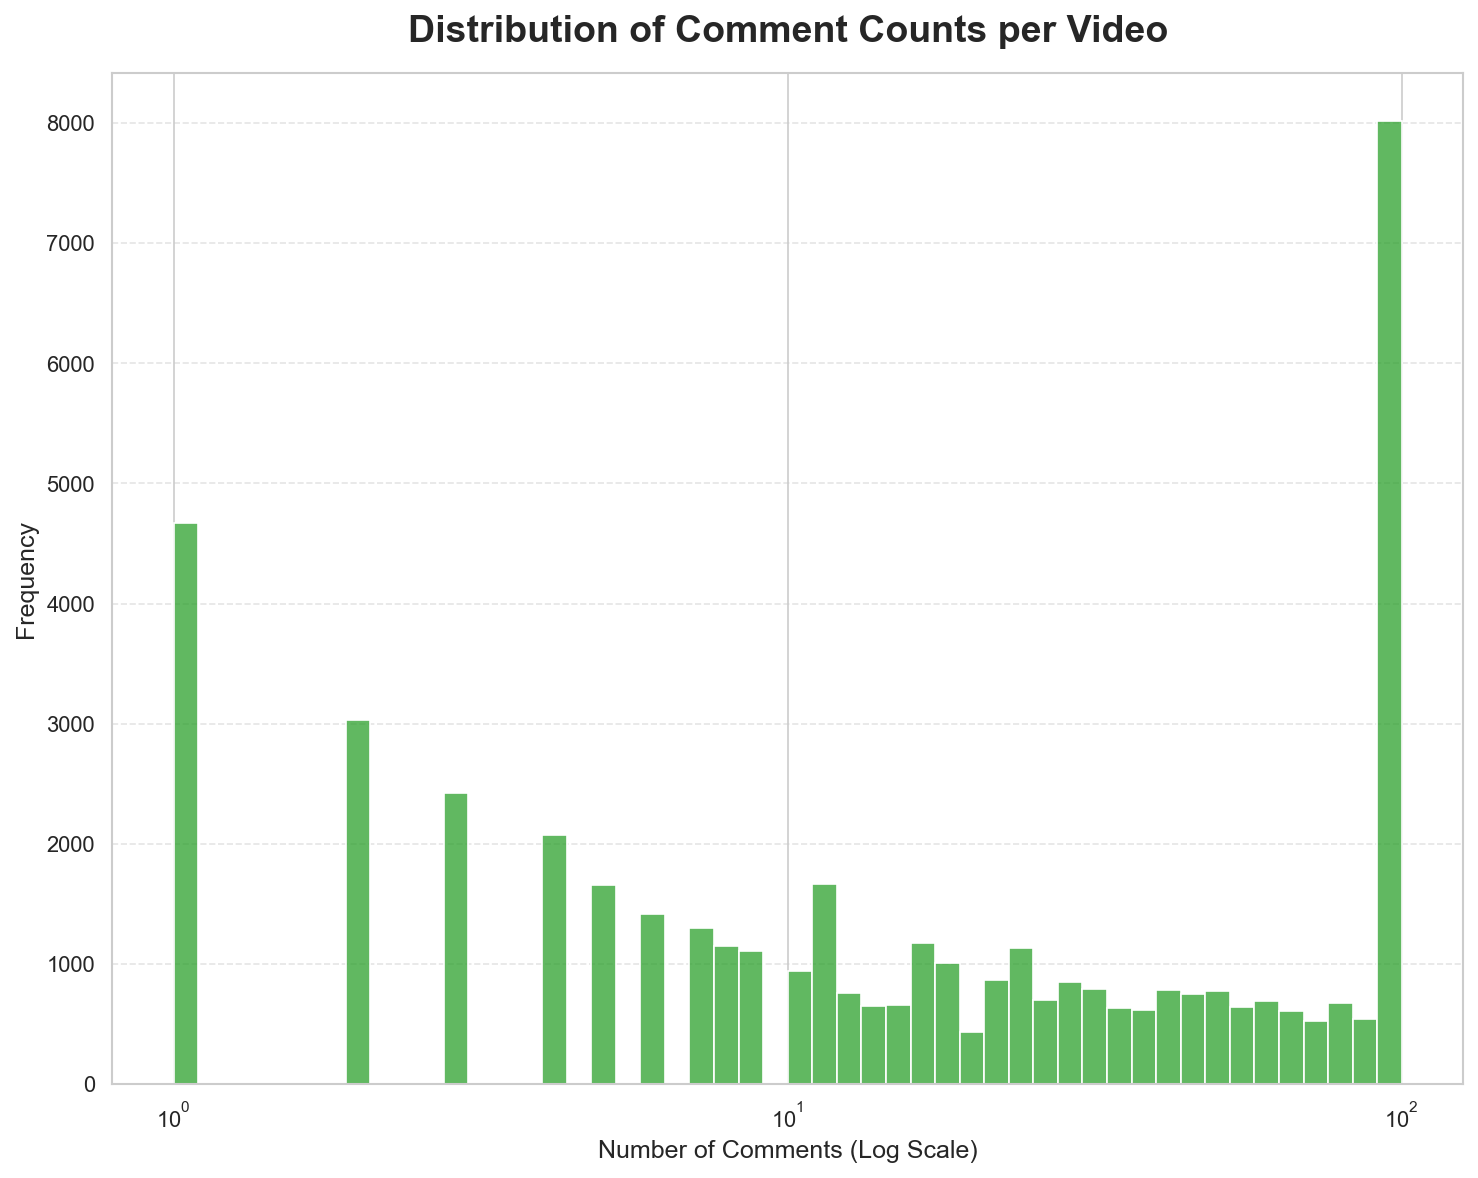

In [18]:
if 'comments_df' in globals():
    comments_per_video = comments_df.groupby('video_id').size().reset_index(name='comment_count')
    
    if not comments_per_video.empty:
        plt.figure(figsize=(10, 8))
        
        sns.histplot(
            comments_per_video['comment_count'], 
            bins=50, 
            log_scale=True, 
            kde=False,
            color=COLOR_NEUTRAL,
            edgecolor="white"
        )
        
        plt.title('Distribution of Comment Counts per Video', weight='bold', pad=15)
        plt.xlabel('Number of Comments (Log Scale)')
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.savefig("figure_9_comments_per_video.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Skipping Figure 9: No data.")

## 14. Analysis 11: Toxicity Trends Over Time (Figure 10)

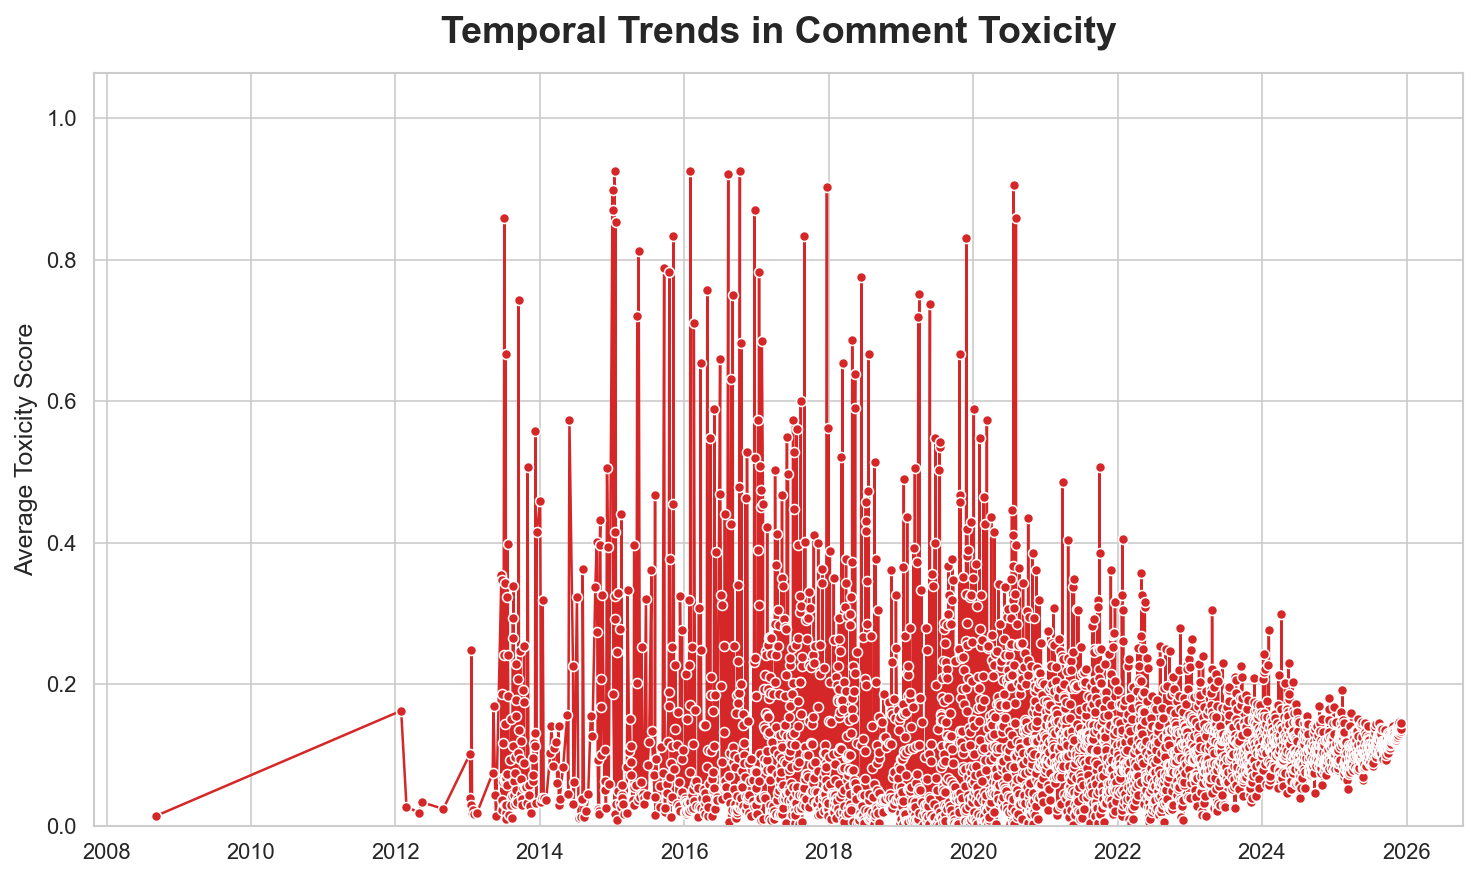

In [14]:
if 'comments_df' in globals():
    plot_df = comments_df.dropna(subset=['toxicity_score'])
    
    daily_toxicity = plot_df.set_index('published_at')['toxicity_score'].resample('D').mean().reset_index()
    daily_toxicity.rename(columns={'published_at': 'Date'}, inplace=True)
    daily_toxicity.dropna(inplace=True)
    
    if not daily_toxicity.empty:
        plt.figure(figsize=(10, 6))
        
        sns.lineplot(
            data=daily_toxicity, 
            x='Date', 
            y='toxicity_score', 
            color="#d62728", 
            marker='o',
            markeredgecolor='white'
        )
        
        plt.title('Temporal Trends in Comment Toxicity', weight='bold', pad=15)
        plt.ylabel('Average Toxicity Score')
        plt.xlabel('')
        plt.ylim(0, max(0.5, daily_toxicity['toxicity_score'].max() * 1.15))
        
        # Format Date Axis nicely
        plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
        plt.xticks(rotation=0)
        
        plt.tight_layout()
        plt.savefig("figure_10_toxicity_over_time.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Skipping Figure 10: No temporal data available.")

## 12. Analysis 12: Top Creators Ranking (Figure 11)

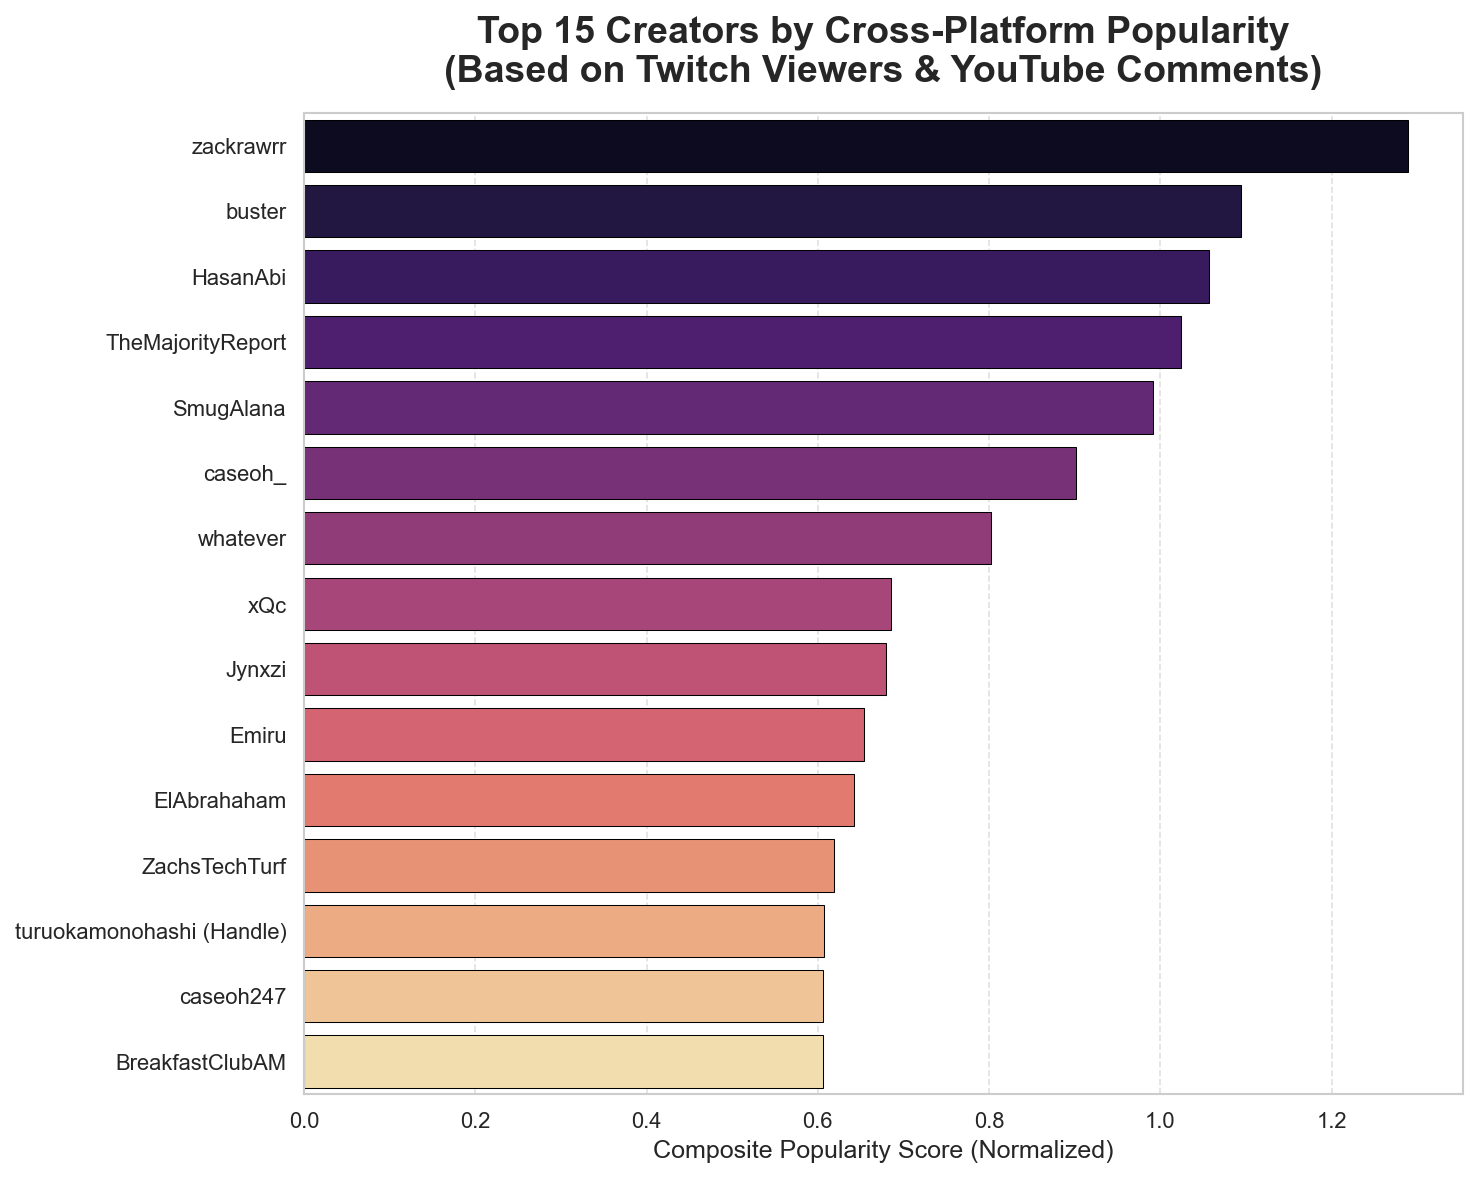

In [15]:
required_dfs = ['twitch_df', 'videos_df', 'map_df', 'users_df']
missing_dfs = [df for df in required_dfs if df not in globals()]

if not missing_dfs:
    try:
        # 1. Twitch Popularity: Average Viewers
        twitch_pop = twitch_df.groupby('user_id')['viewer_count'].mean().reset_index()
        twitch_pop.rename(columns={'viewer_count': 'twitch_metric'}, inplace=True)

        # 2. YouTube Popularity: Views (preferred) or Comment Count (fallback)
        if 'view_count' in videos_df.columns:
            yt_pop = videos_df.groupby('channel_id')['view_count'].sum().reset_index()
            yt_metric_name = 'YouTube Views'
        elif 'comments_df' in globals():
            comments_per_video = comments_df.groupby('video_id').size().reset_index(name='count')
            video_counts = pd.merge(videos_df, comments_per_video, on='video_id')
            yt_pop = video_counts.groupby('channel_id')['count'].sum().reset_index()
            yt_pop.rename(columns={'count': 'view_count'}, inplace=True)
            yt_metric_name = 'YouTube Comments'
        else:
            yt_pop = pd.DataFrame()
            yt_metric_name = 'None'

        if not yt_pop.empty:
            yt_pop.rename(columns={'view_count': 'youtube_metric'}, inplace=True)

            # 3. Merge Data
            merged = pd.merge(yt_pop, map_df, left_on='channel_id', right_on='youtube_channel_id')
            merged = pd.merge(merged, users_df, left_on='twitch_login_name', right_on='login_name')
            final_df = pd.merge(merged, twitch_pop, on='user_id')

            # 3.1. Clean Display Names for Plotting
            def get_renderable_name(row):
                """
                Returns display_name if it's ASCII-compatible (renderable by default fonts).
                Otherwise, returns login_name (which is guaranteed to be ASCII on Twitch).
                """
                d_name = str(row['display_name'])
                l_name = str(row['login_name'])
                try:
                    d_name.encode('latin-1')
                    return d_name
                except UnicodeEncodeError:
                    # If it fails, use the login handle
                    return f"{l_name} (Handle)"

            final_df['plot_label'] = final_df.apply(get_renderable_name, axis=1)

            # 4. Normalize & Score
            final_df['twitch_norm'] = (final_df['twitch_metric'] - final_df['twitch_metric'].min()) / \
                                      (final_df['twitch_metric'].max() - final_df['twitch_metric'].min())
            
            final_df['youtube_norm'] = (final_df['youtube_metric'] - final_df['youtube_metric'].min()) / \
                                       (final_df['youtube_metric'].max() - final_df['youtube_metric'].min())
            
            final_df['popularity_score'] = final_df['twitch_norm'] + final_df['youtube_norm']
            
            # Top 15 Creators
            top_creators = final_df.sort_values('popularity_score', ascending=False).head(15)

            # 5. Plot
            plt.figure(figsize=(10, 8))
            
            sns.barplot(
                data=top_creators,
                x='popularity_score',
                y='plot_label',
                palette='magma',
                edgecolor='black',
                linewidth=0.5
            )

            plt.title(f'Top 15 Creators by Cross-Platform Popularity\n(Based on Twitch Viewers & {yt_metric_name})', weight='bold', pad=15)
            plt.xlabel('Composite Popularity Score (Normalized)')
            plt.ylabel('')
            plt.grid(axis='x', linestyle='--', alpha=0.6)
            
            plt.tight_layout()
            plt.savefig("figure_11_top_creators.png", dpi=300, bbox_inches='tight')
            plt.show()
            
        else:
            print("Skipping Figure 11: No YouTube metric available.")
            
    except Exception as e:
        print(f"Skipping Figure 11: Data processing error - {e}")
else:
    print(f"Skipping Figure 11: Missing required dataframes: {missing_dfs}")

## 12. Analysis 13: Top Twitch Languages (Figure 12)

Top 10 Twitch Stream Languages:
language
en    176777
ru     63792
de     42014
zh     31690
fr     30867
pt     29109
es     26979
ja     13312
it      9916
ko      5978
Name: count, dtype: int64


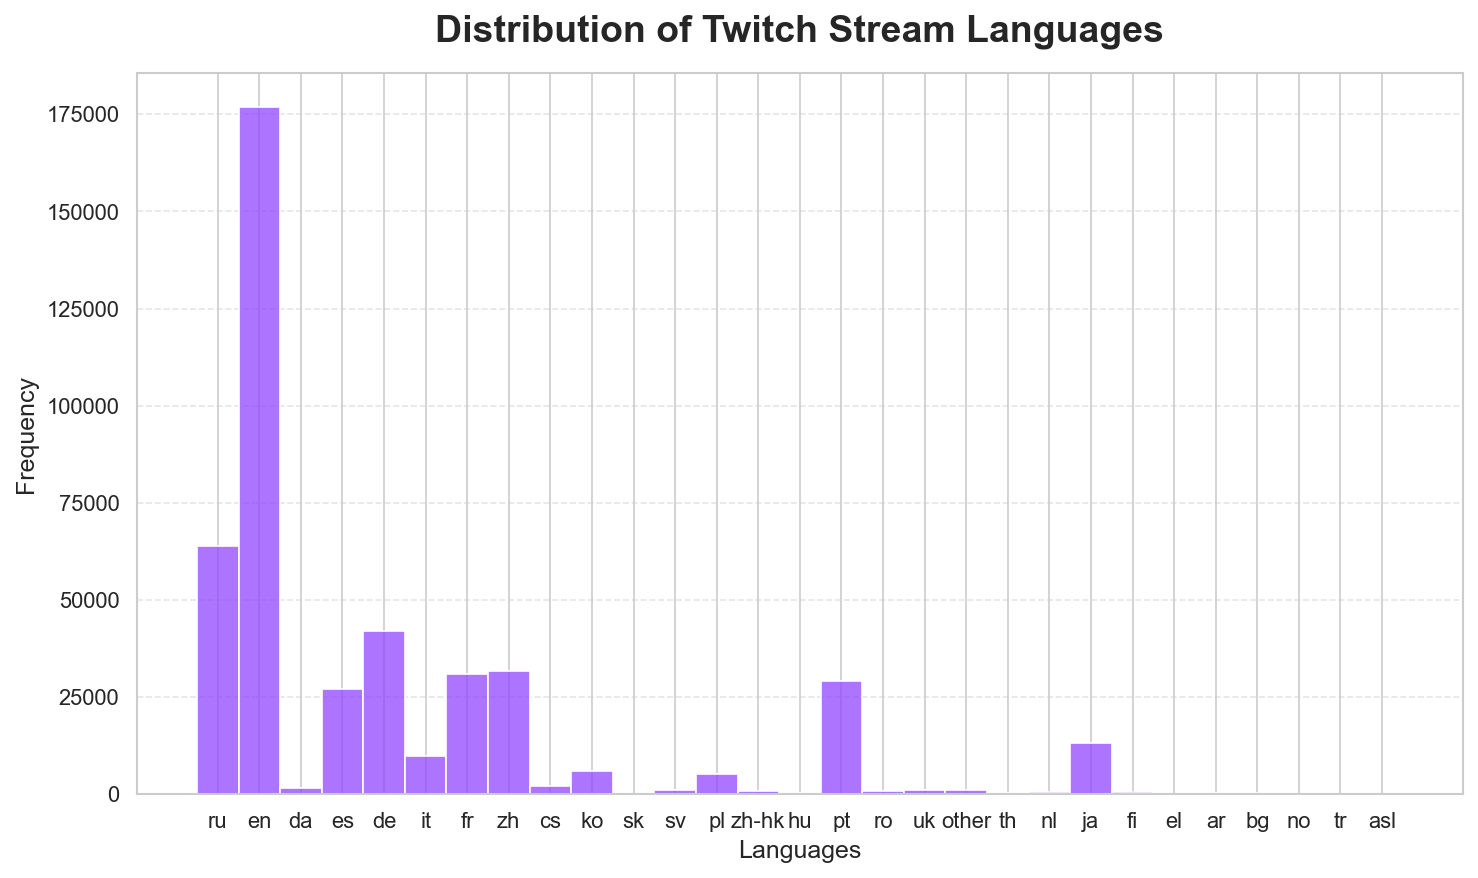

In [ ]:
if 'twitch_df' in globals():
    plt.figure(figsize=(10, 6))
    
    sns.histplot(
        twitch_df['language'], 
        bins=50, 
        log_scale=True, 
        kde=False,
        color=COLOR_TWITCH,
        edgecolor="white"
    )
    
    plt.title('Distribution of Twitch Stream Languages', weight='bold', pad=15)
    plt.xlabel('Languages')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig("figure_12_stream_languages.png", dpi=300, bbox_inches='tight')
    plt.show()